# 💊 Medication OCR Extractor — Algerian Drug Dictionary
### Extract medication names from prescription images using Tesseract + official registered drug list (2025)

> **Pipeline overview:**
> 1. Load the official Algerian registered medication list (`liste-des-medicaments-enrgistres-2025.xlsx`) as the reference drug dictionary
> 2. Preprocess prescription image (deskew, denoise, threshold)
> 3. Run Tesseract OCR to extract raw text
> 4. Match OCR tokens against the drug dictionary (INN + brand names)
> 5. Export results to CSV / JSON

| | |
|---|---|
| **OCR Engine** | Tesseract (local, no API key) |
| **Drug Dictionary** | MIP Algeria — 560 registered products (2025) |
| **Matching** | Fuzzy string matching (rapidfuzz) |
| **Output** | DataFrame + CSV + JSON |

---
## 1 — Install & Import Dependencies

In [1]:
# ── Install required libraries ─────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = {
    "pytesseract"      : "pytesseract",
    "PIL"              : "Pillow",
    "cv2"              : "opencv-python",
    "numpy"            : "numpy",
    "matplotlib"       : "matplotlib",
    "pandas"           : "pandas",
    "openpyxl"         : "openpyxl",
    "rapidfuzz"        : "rapidfuzz",
    "ipywidgets"       : "ipywidgets",
}

for import_name, pkg_name in required.items():
    try:
        __import__(import_name)
        print(f"  ✓  {pkg_name} already installed")
    except ImportError:
        print(f"  ↓  Installing {pkg_name}...")
        pip_install(pkg_name)
        print(f"  ✓  {pkg_name} installed")

print("\n✅ All dependencies ready.")

  ✓  pytesseract already installed
  ✓  Pillow already installed
  ✓  opencv-python already installed
  ✓  numpy already installed
  ✓  matplotlib already installed
  ✓  pandas already installed
  ✓  openpyxl already installed
  ↓  Installing rapidfuzz...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 9.6 MB/s eta 0:00:00
  ✓  rapidfuzz installed
  ✓  ipywidgets already installed

✅ All dependencies ready.


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import os, re, json, warnings
from pathlib import Path

import cv2
import numpy as np
import pytesseract
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from rapidfuzz import fuzz, process

warnings.filterwarnings("ignore")

# ── Tesseract binary path ──────────────────────────────────────────────────
# Uncomment and adjust the line matching your OS if Tesseract is not on your PATH:
# pytesseract.pytesseract.tesseract_cmd = r"/usr/bin/tesseract"                          # Linux
# pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe" # Windows
# pytesseract.pytesseract.tesseract_cmd = r"/usr/local/bin/tesseract"                    # macOS (Homebrew)

try:
    ver = pytesseract.get_tesseract_version()
    print(f"✅ Tesseract version: {ver}")
except Exception as e:
    print(f"⚠️  Tesseract not found on PATH — set tesseract_cmd above.\n   Error: {e}")

print("✅ All imports successful.")

✅ Tesseract version: 4.1.1
✅ All imports successful.


---
## 2 — Load the Drug Dictionary (Algerian Registered Medications 2025)

In [3]:
# ── Load the official MIP Algeria registered medication list ───────────────
# Expected columns (row 17 in the xlsx is the header):
#   N | N°ENREGISTREMENT | CODE | DENOMINATION COMMUNE INTERNATIONALE |
#   NOM DE MARQUE | FORME | DOSAGE | CONDITIONNEMENT

DRUG_DICT_PATH = "/kaggle/input/datasets/israakerrout/medications/liste-des-medicaments-enrgistres-2025.xlsx"  # ← adjust path if needed

df_drugs = pd.read_excel(
    DRUG_DICT_PATH,
    header=16,          # Row 17 (0-indexed = 16) is the header
    usecols=range(8),   # Only the 8 meaningful columns
    engine="openpyxl"
)

# Clean up column names
df_drugs.columns = ["N", "REGISTRATION_NO", "CODE", "INN", "BRAND_NAME", "FORM", "DOSAGE", "PACKAGING"]

# Drop any completely empty rows
df_drugs = df_drugs.dropna(subset=["INN", "BRAND_NAME"], how="all").reset_index(drop=True)

# Normalise text to upper-case for matching
df_drugs["INN_UPPER"]        = df_drugs["INN"].astype(str).str.upper().str.strip()
df_drugs["BRAND_NAME_UPPER"] = df_drugs["BRAND_NAME"].astype(str).str.upper().str.strip()

print(f"✅ Drug dictionary loaded — {len(df_drugs)} registered products")
df_drugs.head(10)

✅ Drug dictionary loaded — 560 registered products


,N,REGISTRATION_NO,CODE,INN,BRAND_NAME,FORM,DOSAGE,PACKAGING,INN_UPPER,BRAND_NAME_UPPER
0,1,352/01 A 003/06/22,01 A 003,CETIRIZINE DICHLORHYDRATE,ARTIZ,COMPRIME PELLICULE SECABLE,10MG,B/10,CETIRIZINE DICHLORHYDRATE,ARTIZ
1,2,003/01 A 005/97/25,01 A 005,DEXCHLORPHENIRAMINE MALEATE,HISTAGAN,COMPRIME SECABLE,2MG,B/30,DEXCHLORPHENIRAMINE MALEATE,HISTAGAN
2,3,003/01 A 007/97/25,01 A 007,DEXCHLORPHENIRAMINE MALEATE,HISTAGAN,SOLUTION BUVABLE,"0,5MG/5ML",FL/125ML,DEXCHLORPHENIRAMINE MALEATE,HISTAGAN
3,4,035/01 A 033/98/25,01 A 033,LORATADINE,LORADINE,COMPRIME PELLICULE,10MG,B/20,LORATADINE,LORADINE
4,5,447/01 A 033/14/25,01 A 033,LORATADINE,LORATADINE BEKER,COMPRIME PELLICULE,10MG,B/30,LORATADINE,LORATADINE BEKER
5,6,073/01 A 034/07/25,01 A 034,LORATADINE,CLARADINE,SOLUTION BUVABLE,1MG/ML,FL./60ML,LORATADINE,CLARADINE
6,7,268/01 A 039/07/22,01 A 039,FEXOFENADINE CHLORHYDRATE,RIFEX 120,COMPRIME PELLICULE,120MG,B/20,FEXOFENADINE CHLORHYDRATE,RIFEX 120
7,8,492/01 A 040/15/25,01 A 040,FEXOFENADINE CHLORHYDRATE,FASTOFEN 180,COMPRIME PELLICULE,180MG,B/20,FEXOFENADINE CHLORHYDRATE,FASTOFEN 180
8,9,268/01 A 040/07/22,01 A 040,FEXOFENADINE CHLORHYDRATE,RIFEX 180,COMPRIME PELLICULE,180MG,B/20,FEXOFENADINE CHLORHYDRATE,RIFEX 180
9,10,088/01 A 041/24,01 A 041,CETIRIZINE DICHLORHYDRATE,ZETREC,SOLUTION BUVABLE EN GOUTTES,10MG/ML,B/FL 30ML,CETIRIZINE DICHLORHYDRATE,ZETREC


In [4]:
# ── Build lookup sets for fast matching ────────────────────────────────────

# All unique INN names (generic names)
inn_list = df_drugs["INN_UPPER"].dropna().unique().tolist()

# All unique brand names
brand_list = df_drugs["BRAND_NAME_UPPER"].dropna().unique().tolist()

# Combined master list for fuzzy matching
all_drug_names = list(set(inn_list + brand_list))

print(f"  INN (generic) names : {len(inn_list)}")
print(f"  Brand names         : {len(brand_list)}")
print(f"  Total unique names  : {len(all_drug_names)}")

  INN (generic) names : 288
  Brand names         : 411
  Total unique names  : 699


---
## 3 — Image Preprocessing

In [5]:
# ── Full preprocessing pipeline ───────────────────────────────────────────

def deskew(image: np.ndarray) -> np.ndarray:
    """Correct tilt caused by non-flat scanning or phone camera angle."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    gray = cv2.bitwise_not(gray)
    coords = np.column_stack(np.where(gray > 0))
    if len(coords) == 0:
        return image
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    if abs(angle) < 0.5:   # skip negligible rotation
        return image
    (h, w) = image.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)


def preprocess_image(image_path: str, debug: bool = True) -> np.ndarray:
    """
    Full preprocessing pipeline for a prescription photo.

    Steps:
      1. Load & convert to grayscale
      2. Upscale if too small (Tesseract works best at ~300 DPI)
      3. Deskew
      4. Denoise
      5. Adaptive thresholding (handles uneven lighting)
      6. Morphological opening (remove small noise dots)

    Returns the processed image as a numpy array.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")

    # ① Grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # ② Upscale — Tesseract performs best at 300 DPI / 2000+ px wide
    h, w = gray.shape
    if w < 1500:
        scale = 1500 / w
        gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
        if debug:
            print(f"  ↑  Upscaled {w}×{h} → {gray.shape[1]}×{gray.shape[0]}")

    # ③ Deskew
    gray = deskew(gray)

    # ④ Denoise
    gray = cv2.fastNlMeansDenoising(gray, h=10, templateWindowSize=7, searchWindowSize=21)

    # ⑤ Adaptive threshold — better than global for non-uniform lighting
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=31, C=12
    )

    # ⑥ Morphological opening — erode then dilate to remove tiny noise
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    processed = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    if debug:
        fig, axes = plt.subplots(1, 3, figsize=(16, 6))
        axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original"); axes[0].axis("off")
        axes[1].imshow(gray, cmap="gray")
        axes[1].set_title("Grayscale + Denoise"); axes[1].axis("off")
        axes[2].imshow(processed, cmap="gray")
        axes[2].set_title("Thresholded (OCR-ready)"); axes[2].axis("off")
        plt.suptitle("Preprocessing Pipeline", fontsize=13)
        plt.tight_layout()
        plt.show()

    return processed


print("✅ Preprocessing function defined.")

✅ Preprocessing function defined.


---
## 4 — OCR Extraction with Tesseract

In [6]:
# ── Tesseract OCR function ─────────────────────────────────────────────────

# Tesseract PSM modes:
#   6  = Assume a single uniform block of text (good for full prescriptions)
#   11 = Sparse text — find as much text as possible in no particular order
#   4  = Assume a single column of text of variable sizes

TESSERACT_CONFIG = r"--oem 3 --psm 6"  # LSTM engine, single text block

# Language: 'fra' for French, 'ara' for Arabic, 'eng' for English
# Install additional language packs:
#   sudo apt install tesseract-ocr-fra tesseract-ocr-ara   (Linux)
#   brew install tesseract-lang                             (macOS)
TESSERACT_LANG = "fra+eng"  # French + English (most Algerian prescriptions)


def run_ocr(processed_image: np.ndarray, lang: str = TESSERACT_LANG,
            config: str = TESSERACT_CONFIG) -> dict:
    """
    Run Tesseract OCR on a preprocessed image.

    Returns:
        dict with keys:
            'text'       : full raw OCR string
            'lines'      : list of non-empty lines
            'word_data'  : Tesseract detailed word-level DataFrame
    """
    pil_img = Image.fromarray(processed_image)

    # Full text
    raw_text = pytesseract.image_to_string(pil_img, lang=lang, config=config)

    # Word-level data with confidence scores
    word_data = pytesseract.image_to_data(
        pil_img, lang=lang, config=config,
        output_type=pytesseract.Output.DATAFRAME
    )
    word_data = word_data[(word_data["conf"] > 0) & (word_data["text"].str.strip() != "")]

    lines = [ln.strip() for ln in raw_text.splitlines() if ln.strip()]

    return {
        "text"      : raw_text,
        "lines"     : lines,
        "word_data" : word_data
    }


print("✅ OCR function defined.")

✅ OCR function defined.


---
## 5 — Medication Matching Against the Drug Dictionary

In [7]:
# ── Fuzzy matching against the drug dictionary ─────────────────────────────

FUZZY_THRESHOLD     = 80   # minimum similarity score (0–100)
MIN_TOKEN_LEN       = 6    # ignore OCR tokens shorter than this (raised from 4)
MIN_LEN_RATIO       = 0.60 # token must be ≥60% the length of the matched drug name
SHORT_TOKEN_CUTOFF  = 8

# ── Keywords that mark the start of the prescription body ─────────────────
# Everything BEFORE these words is header / patient info and must be ignored.
PRESCRIPTION_START_KEYWORDS = [
    "ORDONNANCE",
    "PRESCRIPTION",
    "TRAITEMENT",
    "Rp/",
    "RP/",
]


def slice_after_ordonnance(text: str) -> str:
    """
    Return only the text that comes AFTER the first occurrence of any
    prescription-start keyword (case-insensitive).

    This removes the doctor header, patient name, date, etc. — anything
    before 'ORDONNANCE' — so we never accidentally match 'Amir', 'Ville',
    'gttes', or any other non-drug word that appears in the header.

    If no keyword is found the full text is returned as a fallback.
    """
    text_upper = text.upper()
    earliest_idx = len(text)  # start from the end as sentinel

    for kw in PRESCRIPTION_START_KEYWORDS:
        idx = text_upper.find(kw.upper())
        if idx != -1 and idx < earliest_idx:
            earliest_idx = idx
            found_kw = kw

    if earliest_idx < len(text):
        # Advance past the keyword itself so it is not re-tokenised
        cut = earliest_idx + len(found_kw)
        sliced = text[cut:]
        print(f"  ✂️  Text sliced after '{found_kw}' "
              f"(discarded {earliest_idx} chars of header/patient info)")
        return sliced
    else:
        print("  ⚠️  No prescription-start keyword found — using full OCR text.")
        return text


def match_medications(
    ocr_result  : dict,
    drug_names  : list,
    df_drugs    : pd.DataFrame,
    threshold   : int = FUZZY_THRESHOLD
) -> pd.DataFrame:
    """
    Match OCR tokens against the drug dictionary using fuzzy matching.
    Only text that appears AFTER the ORDONNANCE keyword is processed.

    Args:
        ocr_result : output of run_ocr()
        drug_names : combined list of INN + brand name strings (upper-case)
        df_drugs   : the full drug DataFrame for metadata lookup
        threshold  : minimum fuzzy score to accept a match

    Returns:
        DataFrame of matched medications with metadata from the drug dictionary
    """
    # ── KEY FIX: only look at text after 'ORDONNANCE' ──────────────────────
    full_text = ocr_result["text"]
    text = slice_after_ordonnance(full_text)

    # ── Also filter the word_data DataFrame to the same region ────────────
    # Find the character offset where the prescription body starts
    start_char = len(full_text) - len(text)

    # Tokenise: split on whitespace and punctuation, keep meaningful chunks
    raw_tokens = re.findall(r"[A-Za-zÀ-ÿ]{" + str(MIN_TOKEN_LEN) + r",}", text)

    # Multi-word tokens (bigrams / trigrams) for multi-word INN names
    words = [w for w in raw_tokens]
    bigrams  = [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]
    trigrams = [f"{words[i]} {words[i+1]} {words[i+2]}" for i in range(len(words)-2)]
    all_tokens = words + bigrams + trigrams

    matches = []
    seen = set()  # dedup by matched drug name

    for token in all_tokens:
        norm = token.upper().strip()
        if len(norm) < MIN_TOKEN_LEN:
            continue

        result = process.extractOne(
            norm,
            drug_names,
            scorer=fuzz.WRatio,
            score_cutoff=threshold
        )

        if result is None:
            continue

        matched_name, score, _ = result

        if matched_name in seen:
            continue
        seen.add(matched_name)

        # Look up in the drug DataFrame
        row_inn   = df_drugs[df_drugs["INN_UPPER"]        == matched_name]
        row_brand = df_drugs[df_drugs["BRAND_NAME_UPPER"] == matched_name]
        row = row_inn if not row_inn.empty else row_brand

        if row.empty:
            continue

        first = row.iloc[0]
        matches.append({
            "ocr_token"       : token,
            "matched_name"    : matched_name,
            "match_score"     : round(score, 1),
            "match_type"      : "INN" if not row_inn.empty else "Brand",
            "INN"             : first["INN"],
            "brand_name"      : first["BRAND_NAME"],
            "form"            : first["FORM"],
            "dosage"          : first["DOSAGE"],
            "packaging"       : first["PACKAGING"],
            "registration_no" : first["REGISTRATION_NO"],
            "code"            : first["CODE"],
        })

    df_matches = pd.DataFrame(matches)
    if not df_matches.empty:
        df_matches = df_matches.sort_values("match_score", ascending=False).reset_index(drop=True)
    return df_matches


print("✅ Matching function defined (with ORDONNANCE-aware text slicing).")

✅ Matching function defined (with ORDONNANCE-aware text slicing).


---
## 7 — Run the Full Pipeline

⏳ Step 1/3 — Preprocessing image...
  ↑  Upscaled 760×1134 → 1500×2238


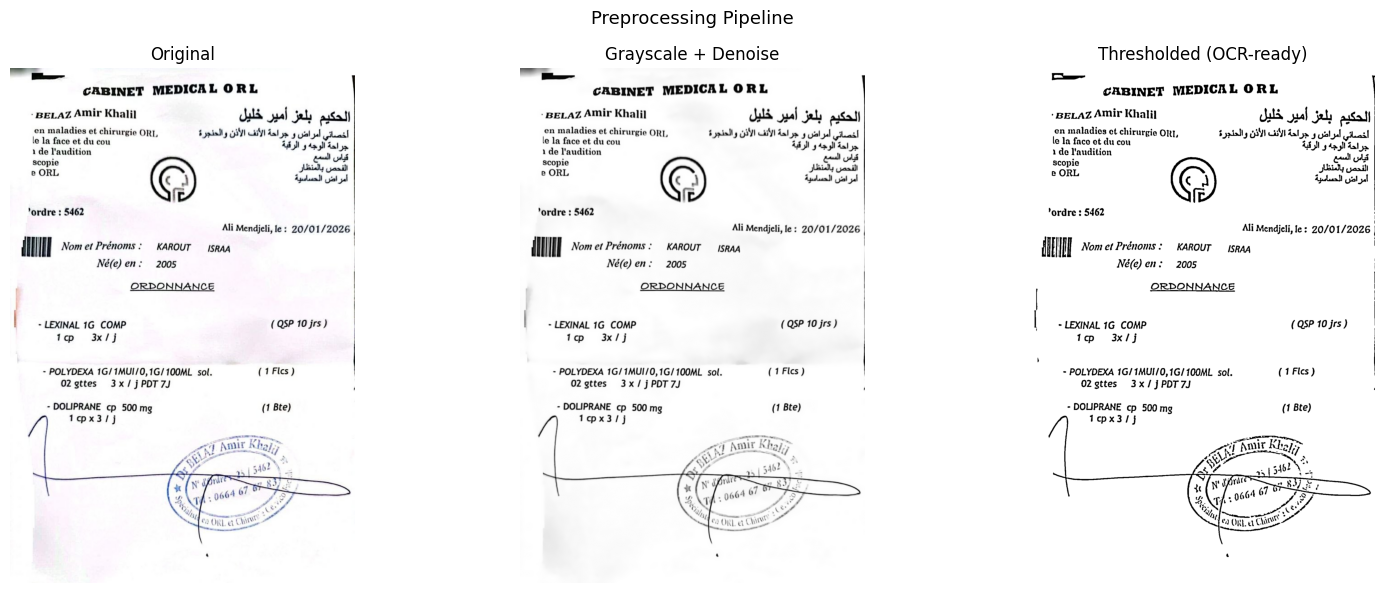

✅ Preprocessing done.


In [8]:
# ── Configuration ──────────────────────────────────────────────────────────
# To use your own image, change this path:
IMAGE_PATH = "/kaggle/input/datasets/israakerrout/ordonnance/ordonnance4.jpg"   # ← replace with your prescription image

# Tweak these if needed:
LANG       = "fra+eng"  # tesseract language(s)
THRESHOLD  = 80         # fuzzy match threshold (80–90 recommended)


# ── Step 1: Preprocess ─────────────────────────────────────────────────────
print("⏳ Step 1/3 — Preprocessing image...")
processed_img = preprocess_image(IMAGE_PATH, debug=True)
print("✅ Preprocessing done.")

In [9]:
# ── Step 2: OCR ────────────────────────────────────────────────────────────
print("⏳ Step 2/3 — Running Tesseract OCR...")
ocr_result = run_ocr(processed_img, lang=LANG)

print("\n" + "="*60)
print("RAW OCR TEXT:")
print("="*60)
print(ocr_result["text"])
print("="*60)
print(f"\n✅ OCR complete — {len(ocr_result['lines'])} text lines extracted.")

⏳ Step 2/3 — Running Tesseract OCR...

RAW OCR TEXT:
_
CABINET MEDICAL ORL
-BELAZ Amir Khalil Jal ual jel auSal|
en maladies ct chirurgie ORI, Byatally AY) uYI dalja y val yd cplaasl
le la face et du cou 44M 5 das! Sala
1 de l'audition Qe Gs
Scopie QUeidy yaaill
ordre : 5462 |
Ali Mendjeli, le: 20/01/2026 |
AEN Nom et Prénoms: KAROUT — IsRAA |
Né(e) en: 2005 |
| ORDONNANCE
| - LEXINAL 1G COMP (QSP 10 jrs)
tcp 3x/j
b
- POLYDEXA 1G/1MUI/0,1G/100ML sol. ( 1 Fics )
O02 gttes 3x/jPDT7J
- DOLIPRANE cp 500 mg (1 Bte)
Tcpx3/j
pe,
anil AMT Khayy
<a bye .
SN
= 7 a. 34 ° 4
7
. 9604 6 ¢ s ;
OO
ca OR ane °


✅ OCR complete — 28 text lines extracted.


In [10]:
# ── Step 3: Match against drug dictionary ─────────────────────────────────
print("⏳ Step 3/3 — Matching against drug dictionary...")
df_matches = match_medications(ocr_result, all_drug_names, df_drugs, threshold=THRESHOLD)

print(f"\n✅ Matching complete — {len(df_matches)} medication(s) identified.")

if df_matches.empty:
    print("\n⚠️  No medications matched. Try lowering THRESHOLD (e.g., 70) or check the OCR output above.")
else:
    print()
    display(df_matches)

⏳ Step 3/3 — Matching against drug dictionary...
  ✂️  Text sliced after 'ORDONNANCE' (discarded 312 chars of header/patient info)

✅ Matching complete — 2 medication(s) identified.



,ocr_token,matched_name,match_score,match_type,INN,brand_name,form,dosage,packaging,registration_no,code
0,LEXINAL,LEXINAL,100.0,Brand,CEFALEXINE MONOHYDRATEE EXPRIME EN CEFALEXINE,LEXINAL,COMPRIME PELLICULE,1G,B/12,039/13 B 223/18/25,13 B 223
1,DOLIPRANE,DOLIPRANE,100.0,Brand,PARACETAMOL,DOLIPRANE,POUDRE POUR SOLUTION BUVABLE EN SACHET DOSE,300MG,B/12,201/03 B 046/00/25,03 B 046


---
## 8 — Visualise Matches on the Original Image

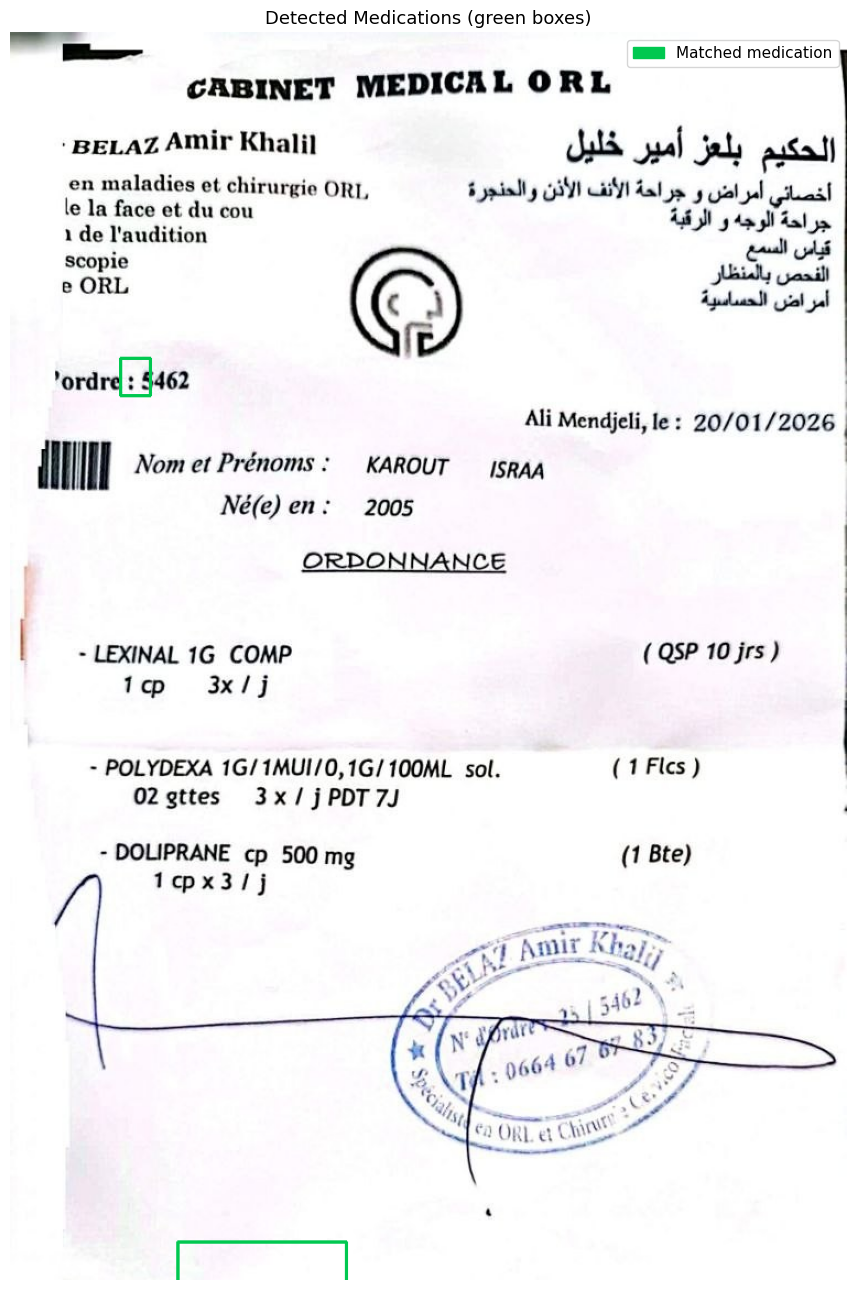

In [11]:
# ── Highlight matched drug tokens in the OCR word-level output ─────────────

def visualise_matches(image_path: str, ocr_result: dict, df_matches: pd.DataFrame):
    """Draw bounding boxes around OCR words that matched a drug name."""
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if df_matches.empty:
        print("No matches to visualise.")
        return

    matched_tokens = set(df_matches["ocr_token"].str.upper())
    word_data = ocr_result["word_data"]

    for _, row in word_data.iterrows():
        word = str(row["text"]).upper()
        # Check if this word is part of any matched token
        if any(word in tok for tok in matched_tokens):
            x, y, w, h = int(row["left"]), int(row["top"]), int(row["width"]), int(row["height"])
            cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 200, 80), 2)

    plt.figure(figsize=(10, 13))
    plt.imshow(img_rgb)
    plt.axis("off")
    green_patch = mpatches.Patch(color=(0, 200/255, 80/255), label="Matched medication")
    plt.legend(handles=[green_patch], loc="upper right", fontsize=11)
    plt.title("Detected Medications (green boxes)", fontsize=13)
    plt.tight_layout()
    plt.show()


visualise_matches(IMAGE_PATH, ocr_result, df_matches)

---
## 9 — Export Results

In [12]:
# ── Export to CSV ──────────────────────────────────────────────────────────
if not df_matches.empty:
    csv_path = "extracted_medications.csv"
    df_matches.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"✅ CSV saved → {csv_path}")

    # ── Export to JSON ─────────────────────────────────────────────────────
    json_path = "extracted_medications.json"
    result_json = {
        "source_image"    : IMAGE_PATH,
        "medications_found": len(df_matches),
        "medications"     : df_matches.to_dict(orient="records")
    }
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(result_json, f, ensure_ascii=False, indent=2)
    print(f"✅ JSON saved → {json_path}")

    print("\n📋 Final extracted medications:")
    display(df_matches[["INN", "brand_name", "dosage", "form", "match_score", "match_type"]])
else:
    print("⚠️  Nothing to export — no medications detected.")

✅ CSV saved → extracted_medications.csv
✅ JSON saved → extracted_medications.json

📋 Final extracted medications:


,INN,brand_name,dosage,form,match_score,match_type
0,CEFALEXINE MONOHYDRATEE EXPRIME EN CEFALEXINE,LEXINAL,1G,COMPRIME PELLICULE,100.0,Brand
1,PARACETAMOL,DOLIPRANE,300MG,POUDRE POUR SOLUTION BUVABLE EN SACHET DOSE,100.0,Brand


---
## Notes & Tips

| Topic | Advice |
|---|---|
| **Image quality** | 300 DPI minimum; avoid shadows and blur |
| **Language pack** | Install `tesseract-ocr-fra` for better French results |
| **Threshold tuning** | Lower `FUZZY_THRESHOLD` (e.g. 70) to catch more; raise (e.g. 90) to reduce false positives |
| **Arabic prescriptions** | Add `ara` to `TESSERACT_LANG` and install `tesseract-ocr-ara` |
| **Multi-word INNs** | The bigram/trigram tokeniser handles names like `CETIRIZINE DICHLORHYDRATE` |
| **Updating the dict** | Replace the `.xlsx` file — the notebook auto-reloads on Section 2 |
| **Kaggle** | Set `IMAGE_PATH` to your Kaggle input path (e.g. `/kaggle/input/.../ordonnance.jpg`) |